# Eksplorasi Data Ekonomi Indonesia

**Tujuan:** Mengenal struktur data ekonomi makro Indonesia dan membuat visualisasi dasar.

**Sumber data:** World Bank Open Data (data.worldbank.org)

**Indikator yang dianalisis:**
- GDP per kapita (current USD)
- Tingkat inflasi (%)
- Tingkat pengangguran (%)
- Pertumbuhan GDP (%)

---

## 0. Setup — import library

In [1]:
# Install dulu kalau belum ada (jalankan sekali di terminal):
# pip install pandas matplotlib seaborn requests

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setting tampilan
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
pd.set_option('display.float_format', '{:.2f}'.format)

print('Library berhasil di-import!')

Library berhasil di-import!


## 1. Load data

Data diambil dari World Bank. Kamu bisa download manual dari:
https://data.worldbank.org/country/indonesia

Atau kita buat data sample dulu untuk latihan:

In [2]:
# Data sample Indonesia 2000-2022 (dari World Bank)
data = {
    'tahun': list(range(2000, 2023)),
    'gdp_per_kapita': [
        857, 893, 921, 1024, 1165, 1386, 1663, 1923, 2244, 2346,
        3178, 3689, 3740, 3692, 3879, 3840, 3607, 3877, 3894, 4174,
        3911, 4292, 4788
    ],
    'inflasi': [
        3.72, 11.50, 11.89, 6.75, 6.06, 10.45, 13.11, 6.41, 9.78, 4.81,
        5.13, 5.36, 4.28, 6.97, 6.42, 6.36, 3.53, 3.81, 3.20, 2.72,
        1.68, 1.56, 4.21
    ],
    'pengangguran': [
        6.08, 8.10, 9.06, 9.67, 9.86, 11.24, 10.28, 9.11, 8.39, 7.87,
        7.14, 6.56, 6.13, 6.17, 5.94, 6.18, 5.61, 5.50, 5.34, 5.28,
        7.07, 6.49, 5.86
    ],
    'pertumbuhan_gdp': [
        4.92, 3.64, 4.50, 4.78, 5.03, 5.69, 5.50, 6.35, 6.01, 4.63,
        6.22, 6.49, 6.23, 5.56, 5.01, 4.79, 5.03, 5.07, 5.17, 5.02,
        -2.07, 3.69, 5.31
    ]
}

df = pd.DataFrame(data)
df = df.set_index('tahun')

print(f'Dataset: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset: 23 baris, 4 kolom


,gdp_per_kapita,inflasi,pengangguran,pertumbuhan_gdp
tahun,,,,
2000,857,3.72,6.08,4.92
2001,893,11.50,8.10,3.64
2002,921,11.89,9.06,4.50
2003,1024,6.75,9.67,4.78
2004,1165,6.06,9.86,5.03


## 2. Statistik deskriptif

In [3]:
df.describe()

,gdp_per_kapita,inflasi,pengangguran,pertumbuhan_gdp
count,23.00,23.00,23.00,23.00
mean,2825.35,6.07,7.34,4.89
std,1322.85,3.26,1.78,1.69
min,857.00,1.56,5.28,-2.07
25%,1524.50,3.77,6.01,4.79
50%,3607.00,5.36,6.56,5.03
75%,3878.00,6.86,8.73,5.62
max,4788.00,13.11,11.24,6.49


In [4]:
# Identifikasi tahun anomali
print('=== Nilai Minimum ===')
for col in df.columns:
    idx = df[col].idxmin()
    print(f'{col}: {df[col].min():.2f} (tahun {idx})')

print('\n=== Nilai Maksimum ===')
for col in df.columns:
    idx = df[col].idxmax()
    print(f'{col}: {df[col].max():.2f} (tahun {idx})')

=== Nilai Minimum ===
gdp_per_kapita: 857.00 (tahun 2000)
inflasi: 1.56 (tahun 2021)
pengangguran: 5.28 (tahun 2019)
pertumbuhan_gdp: -2.07 (tahun 2020)

=== Nilai Maksimum ===
gdp_per_kapita: 4788.00 (tahun 2022)
inflasi: 13.11 (tahun 2006)
pengangguran: 11.24 (tahun 2005)
pertumbuhan_gdp: 6.49 (tahun 2011)


## 3. Visualisasi tren

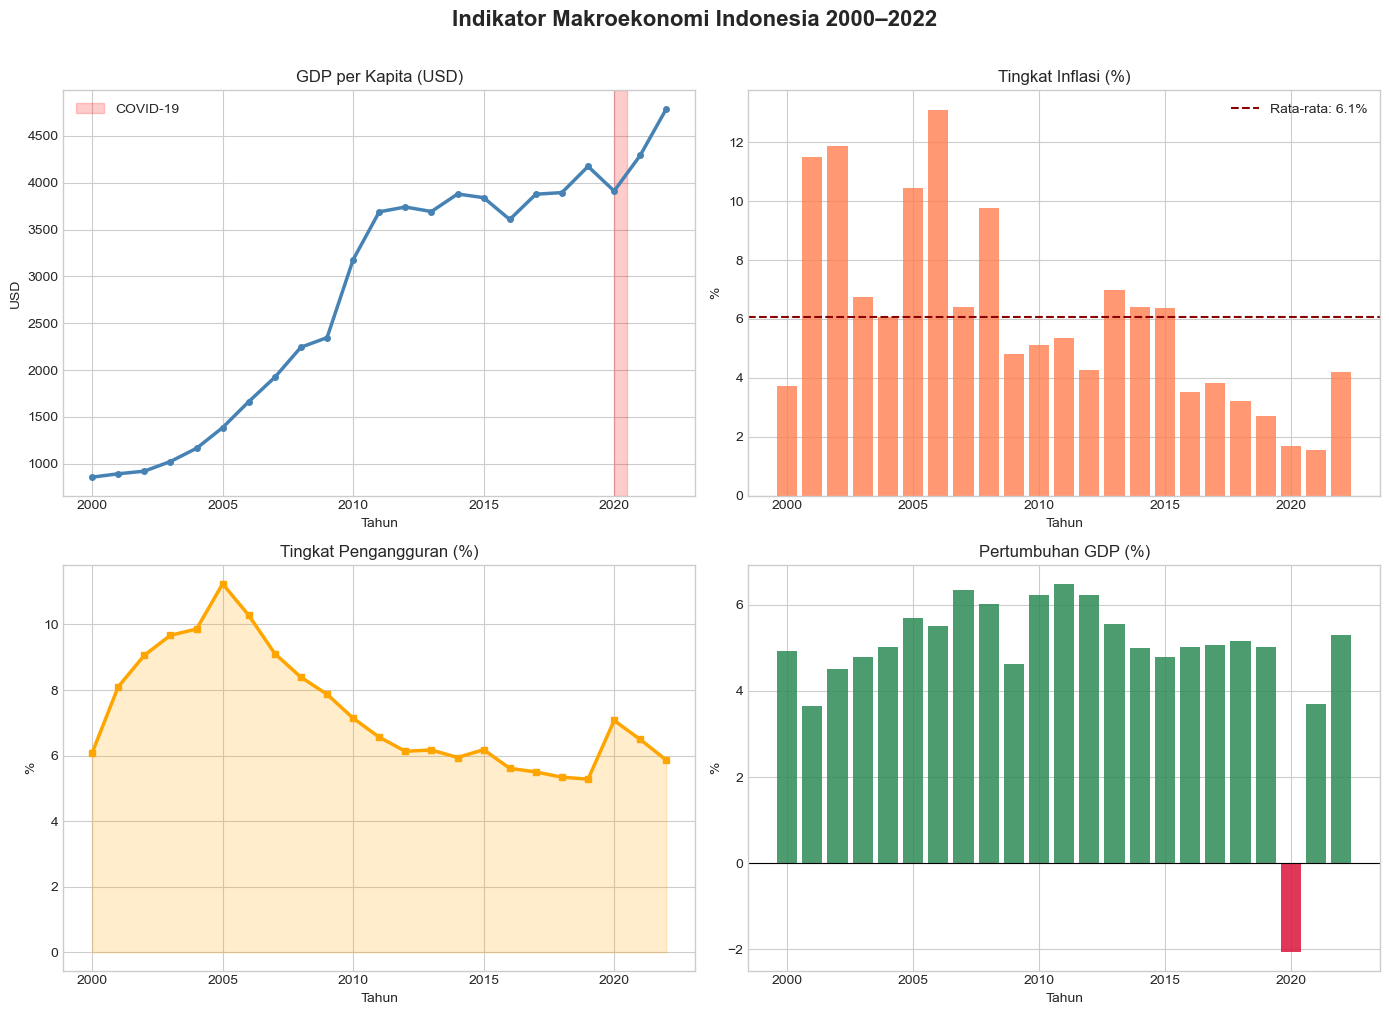

Grafik disimpan di outputs/figures/


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Indikator Makroekonomi Indonesia 2000–2022', 
             fontsize=16, fontweight='bold', y=1.01)

# GDP per kapita
axes[0,0].plot(df.index, df['gdp_per_kapita'], color='steelblue', linewidth=2.5, marker='o', markersize=4)
axes[0,0].set_title('GDP per Kapita (USD)')
axes[0,0].set_xlabel('Tahun')
axes[0,0].set_ylabel('USD')
axes[0,0].axvspan(2020, 2020.5, alpha=0.2, color='red', label='COVID-19')
axes[0,0].legend()

# Inflasi
axes[0,1].bar(df.index, df['inflasi'], color='coral', alpha=0.8)
axes[0,1].axhline(y=df['inflasi'].mean(), color='darkred', linestyle='--', 
                   linewidth=1.5, label=f'Rata-rata: {df["inflasi"].mean():.1f}%')
axes[0,1].set_title('Tingkat Inflasi (%)')
axes[0,1].set_xlabel('Tahun')
axes[0,1].set_ylabel('%')
axes[0,1].legend()

# Pengangguran
axes[1,0].plot(df.index, df['pengangguran'], color='orange', linewidth=2.5, marker='s', markersize=4)
axes[1,0].fill_between(df.index, df['pengangguran'], alpha=0.2, color='orange')
axes[1,0].set_title('Tingkat Pengangguran (%)')
axes[1,0].set_xlabel('Tahun')
axes[1,0].set_ylabel('%')

# Pertumbuhan GDP
colors = ['crimson' if x < 0 else 'seagreen' for x in df['pertumbuhan_gdp']]
axes[1,1].bar(df.index, df['pertumbuhan_gdp'], color=colors, alpha=0.85)
axes[1,1].axhline(y=0, color='black', linewidth=0.8)
axes[1,1].set_title('Pertumbuhan GDP (%)')
axes[1,1].set_xlabel('Tahun')
axes[1,1].set_ylabel('%')

plt.tight_layout()
plt.savefig('../outputs/figures/01_tren_makroekonomi_indonesia.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan di outputs/figures/')

## 4. Analisis korelasi

Apakah ada hubungan antara inflasi dan pengangguran? (Phillips Curve)

In [6]:
# Matriks korelasi
corr_matrix = df.corr()
print('Matriks korelasi:')
print(corr_matrix.round(3))

Matriks korelasi:
                 gdp_per_kapita  inflasi  pengangguran  pertumbuhan_gdp
gdp_per_kapita             1.00    -0.66         -0.78            -0.10
inflasi                   -0.66     1.00          0.71             0.27
pengangguran              -0.78     0.71          1.00             0.06
pertumbuhan_gdp           -0.10     0.27          0.06             1.00


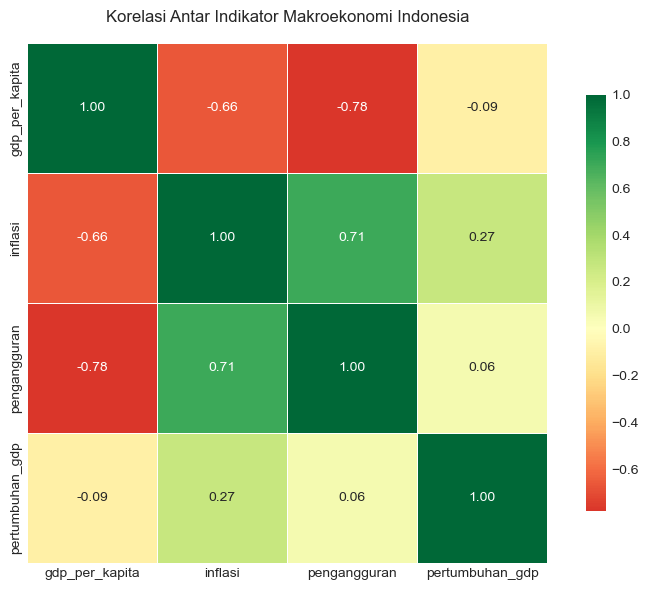

In [7]:
# Heatmap korelasi
plt.figure(figsize=(8, 6))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(i):
        mask.iloc[i, j] = True

sns.heatmap(corr_matrix, 
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Korelasi Antar Indikator Makroekonomi Indonesia', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/01_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interpretasi

**Temuan utama:**

1. *Dalam rentang waktu 22 tahun, Pertumbuhan GDP baru pertama kali bernilai negatif pada tahun 2020, hal ini disebabkan pada tahun tersebut terjadi fenomena global Covid-19. Fenomena tersebut membuat perekonomian hampir lumpuh total dan menjadi tidak efektif. Sehingga kegiatan perekonomian pun turun drastis.*

---
*Analisis oleh: Armandya Danu | Universitas Brawijaya | 29 Mei 2026*